# Beeswarm Plots with plotnine-extra

Beeswarm plots display individual observations along a categorical axis. Points
are offset to reduce overlap, so dense regions remain visible without replacing
observations with a summary statistic.

plotnine-extra provides two geoms ported from the R package
**ggbeeswarm**:

* `geom_beeswarm()` for collision-avoiding point placement.
* `geom_quasirandom()` for density-aware quasi-random jitter.

## Libraries and data

The examples use the **Iris** dataset, with measurements for three iris
species.

In [1]:
from plotnine_extra import (
    ggplot,
    aes,
    geom_beeswarm,
    geom_quasirandom,
    geom_boxplot,
    geom_violin,
    labs,
    theme_minimal,
    scale_color_brewer,
    scale_fill_brewer,
    coord_flip,
    guides,
    guide_legend,
)
from plotnine_extra.data import iris

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Basic beeswarm plot

Map a categorical variable to `x` and a continuous variable to `y`. The geom
offsets points just enough to reduce overlap.

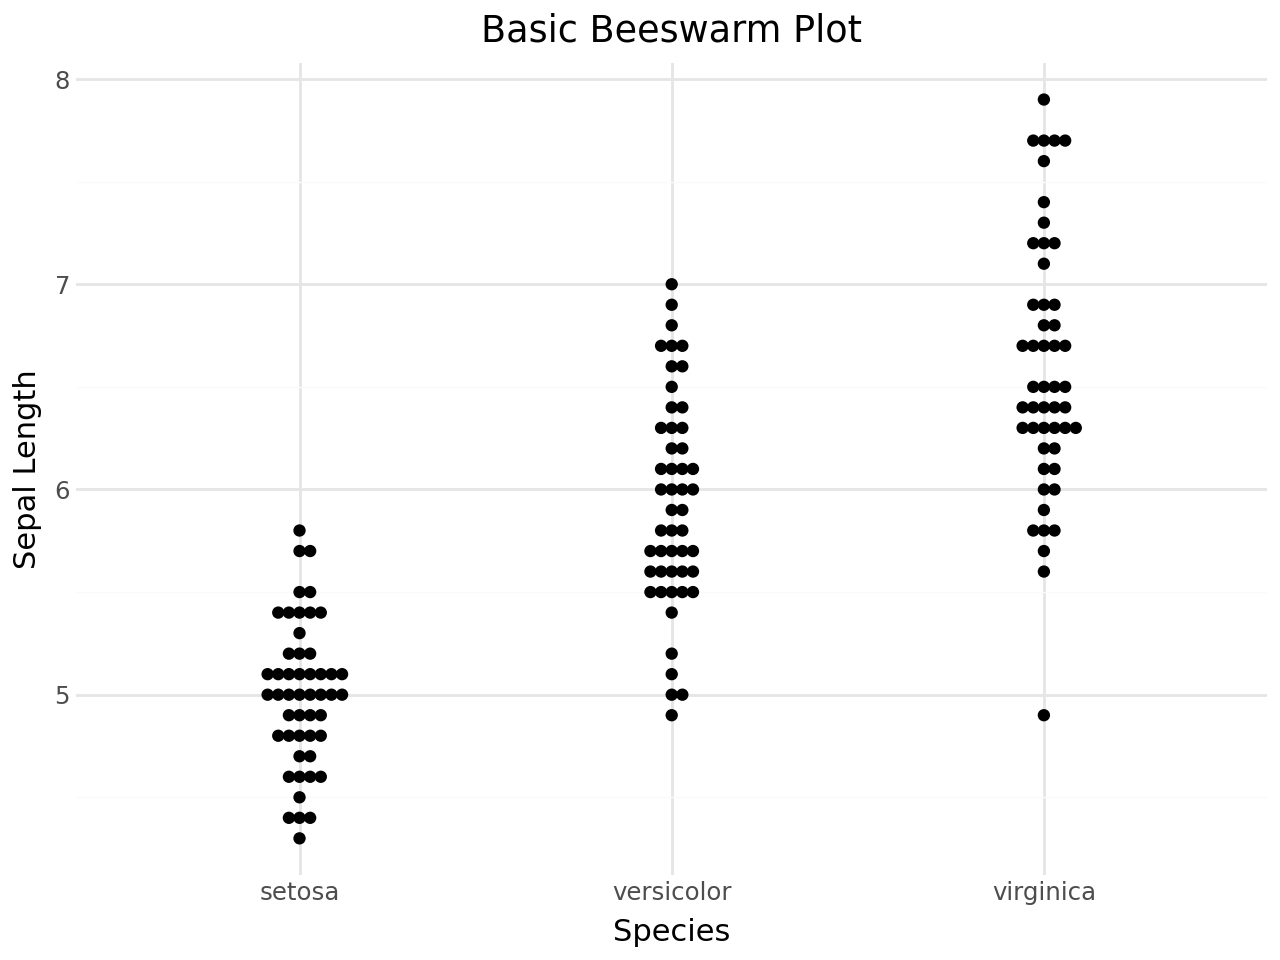

In [2]:
(
    ggplot(iris, aes(x="species", y="sepal_length"))
    + geom_beeswarm()
    + labs(
        title="Basic Beeswarm Plot",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Coloring by group

Map the `color` aesthetic to the grouping variable to
distinguish species.

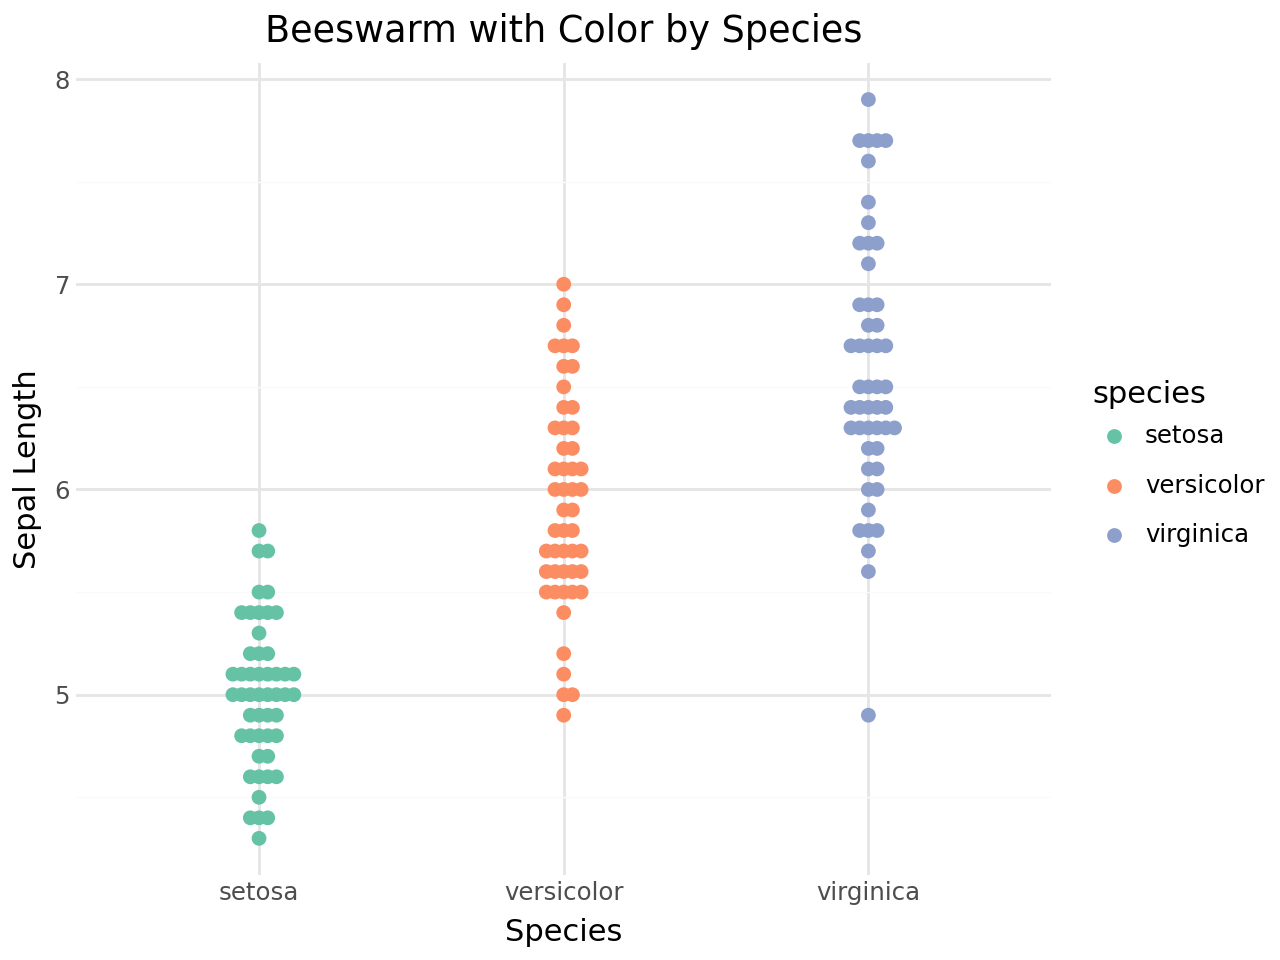

In [3]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title="Beeswarm with Color by Species",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## The `cex` parameter

`cex` controls spacing between points. Higher values spread points farther
apart; lower values pack them more tightly.

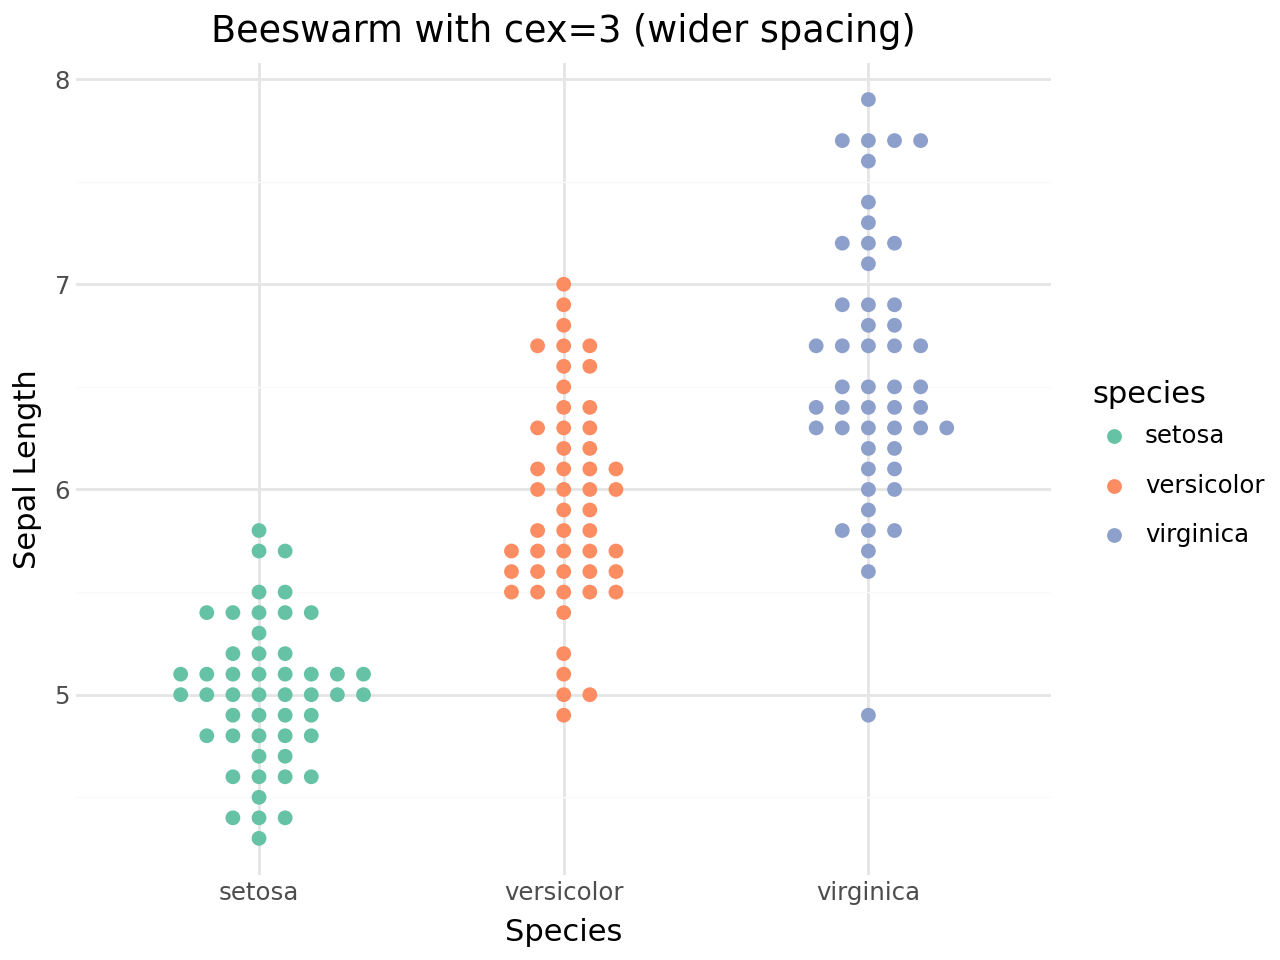

In [4]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(cex=3, size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title="Beeswarm with cex=3 (wider spacing)",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Beeswarm methods

`geom_beeswarm()` supports five layout methods:

| Method | Description |
|---|---|
| `"swarm"` | Default: shifts points sideways to avoid overlap |
| `"compactswarm"` | Tighter packing variant |
| `"center"` | Square grid, centred |
| `"hex"` | Hexagonal grid |
| `"square"` | Regular square grid |

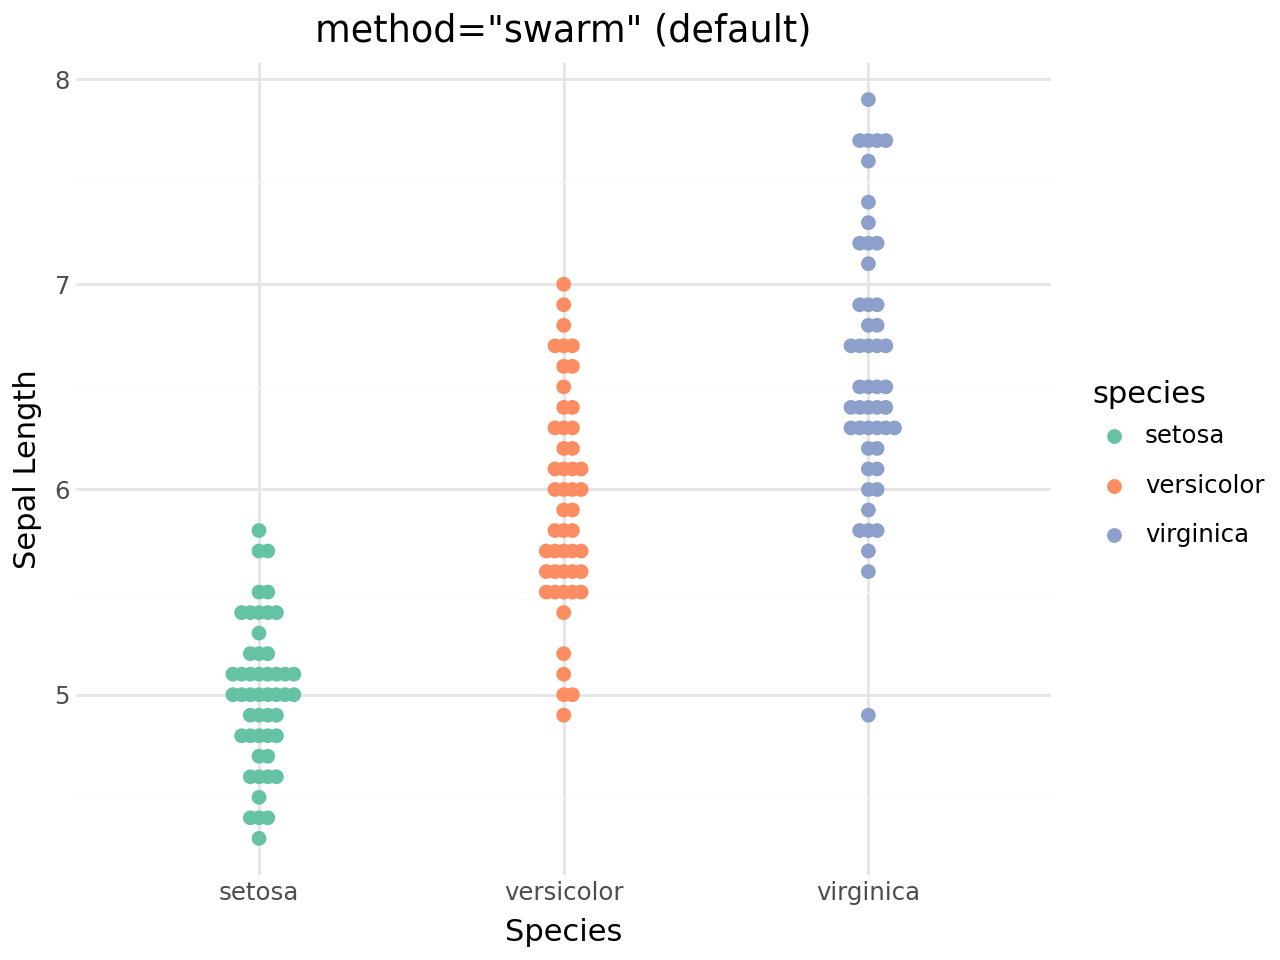

In [5]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(method="swarm", size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title='method="swarm" (default)',
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

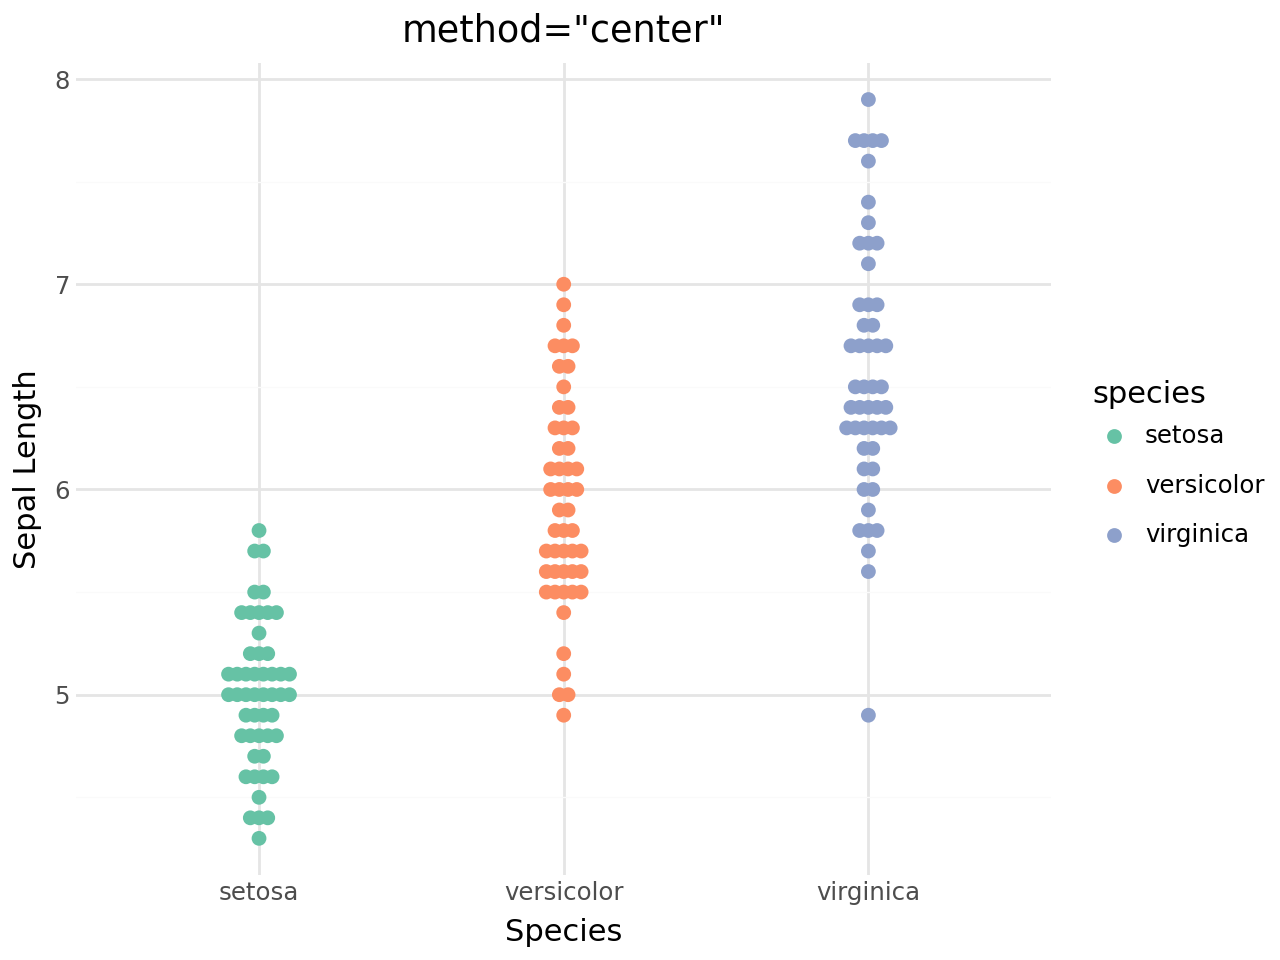

In [6]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(method="center", size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title='method="center"',
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

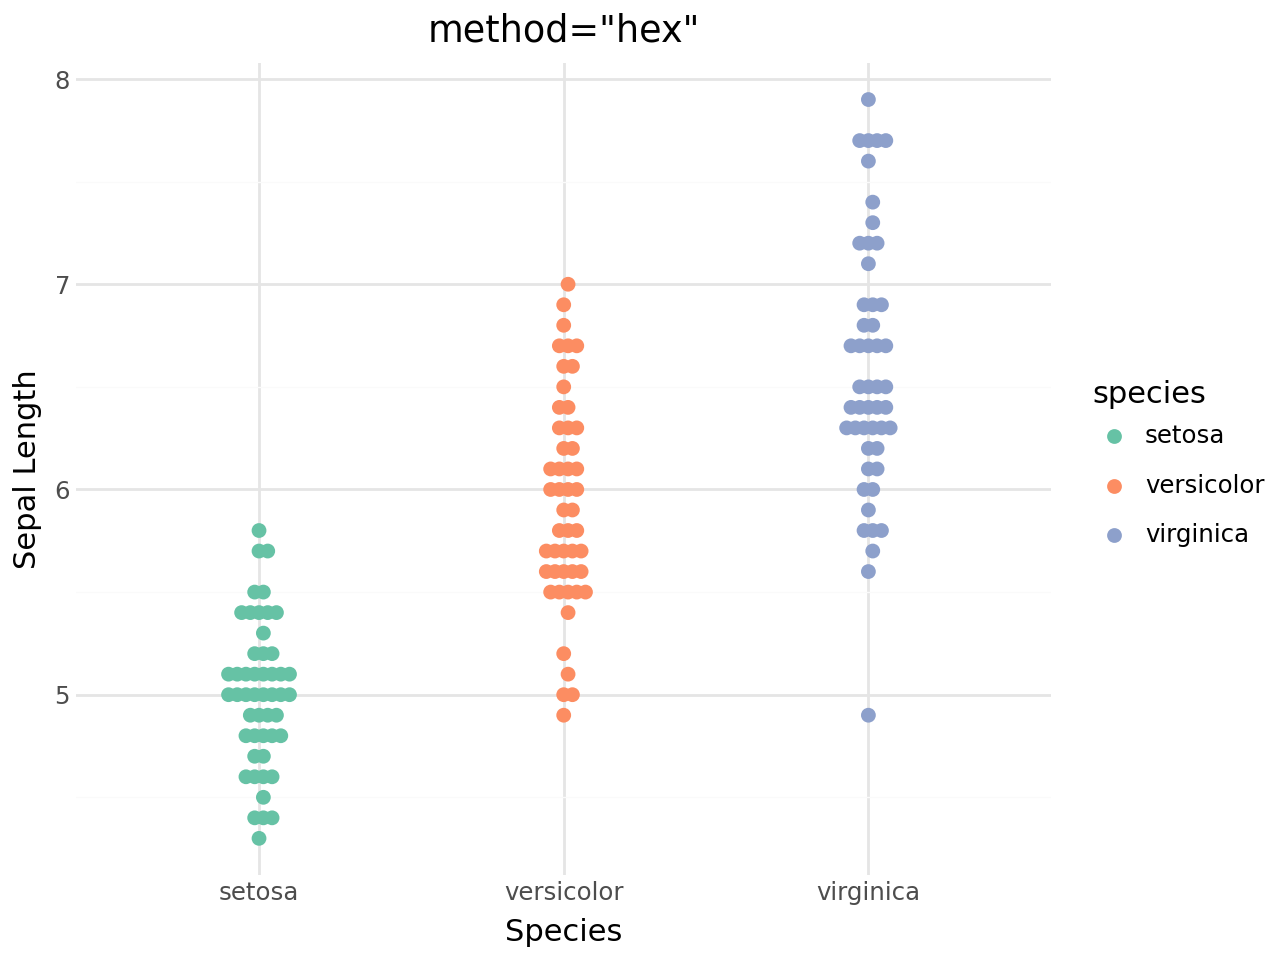

In [7]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(method="hex", size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title='method="hex"',
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

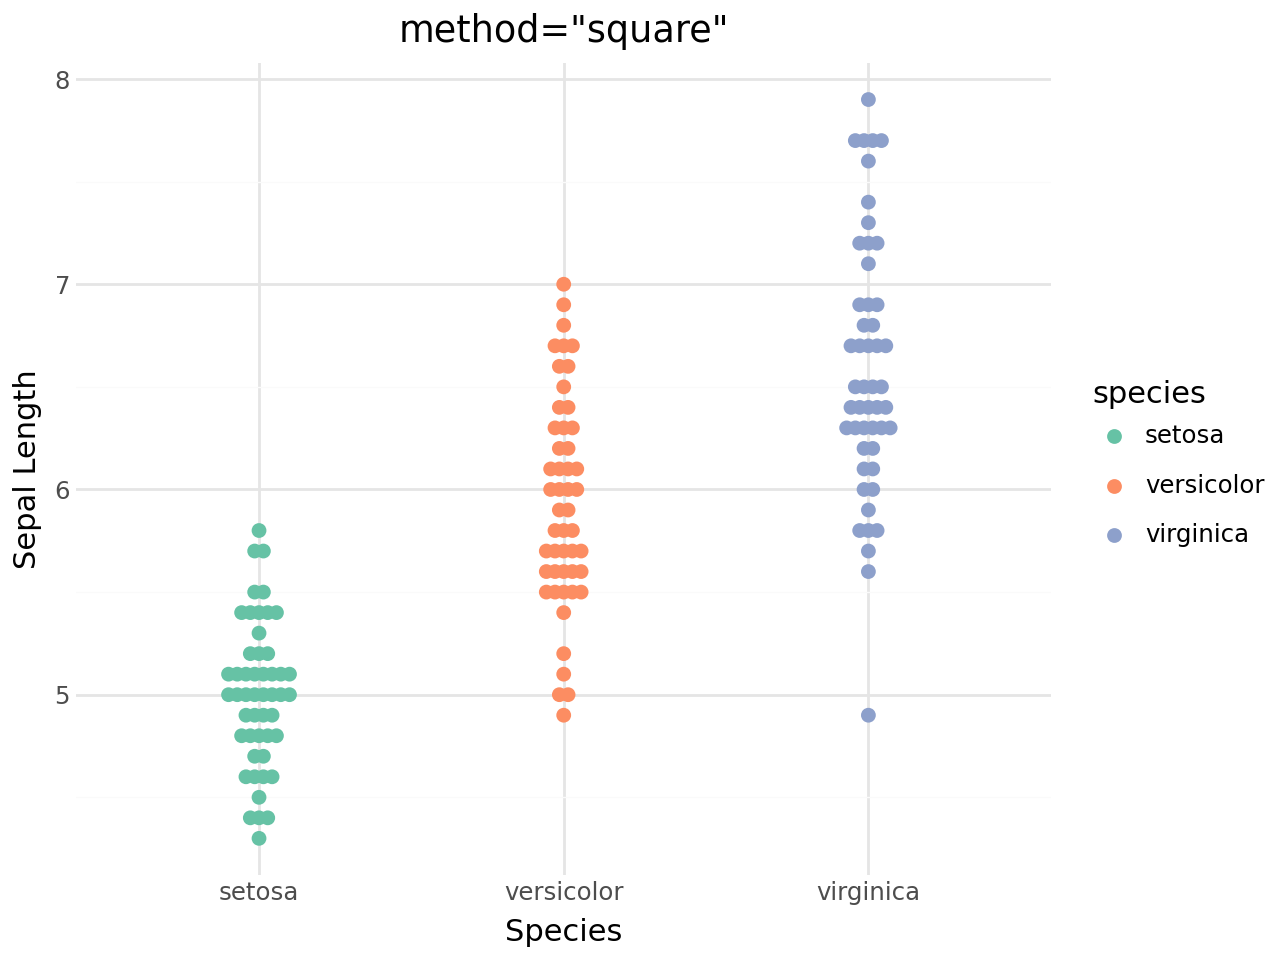

In [8]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(method="square", size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title='method="square"',
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Side control

The `side` parameter determines whether points are spread
to both sides of the centre line or to one side only:

* `side=0`: both sides (default)
* `side=1`: right / up only
* `side=-1`: left / down only

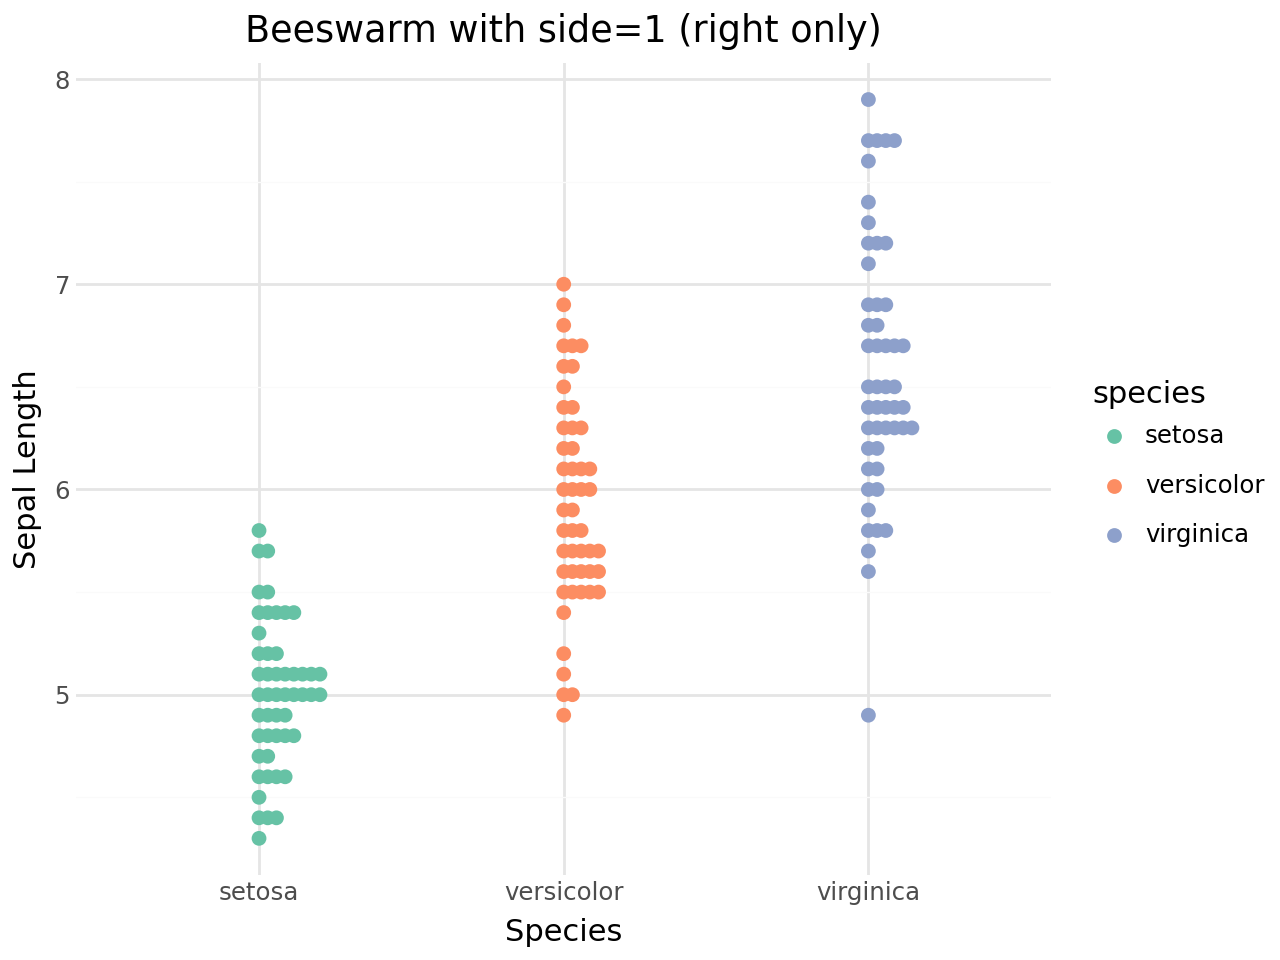

In [9]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(side=1, size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title="Beeswarm with side=1 (right only)",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

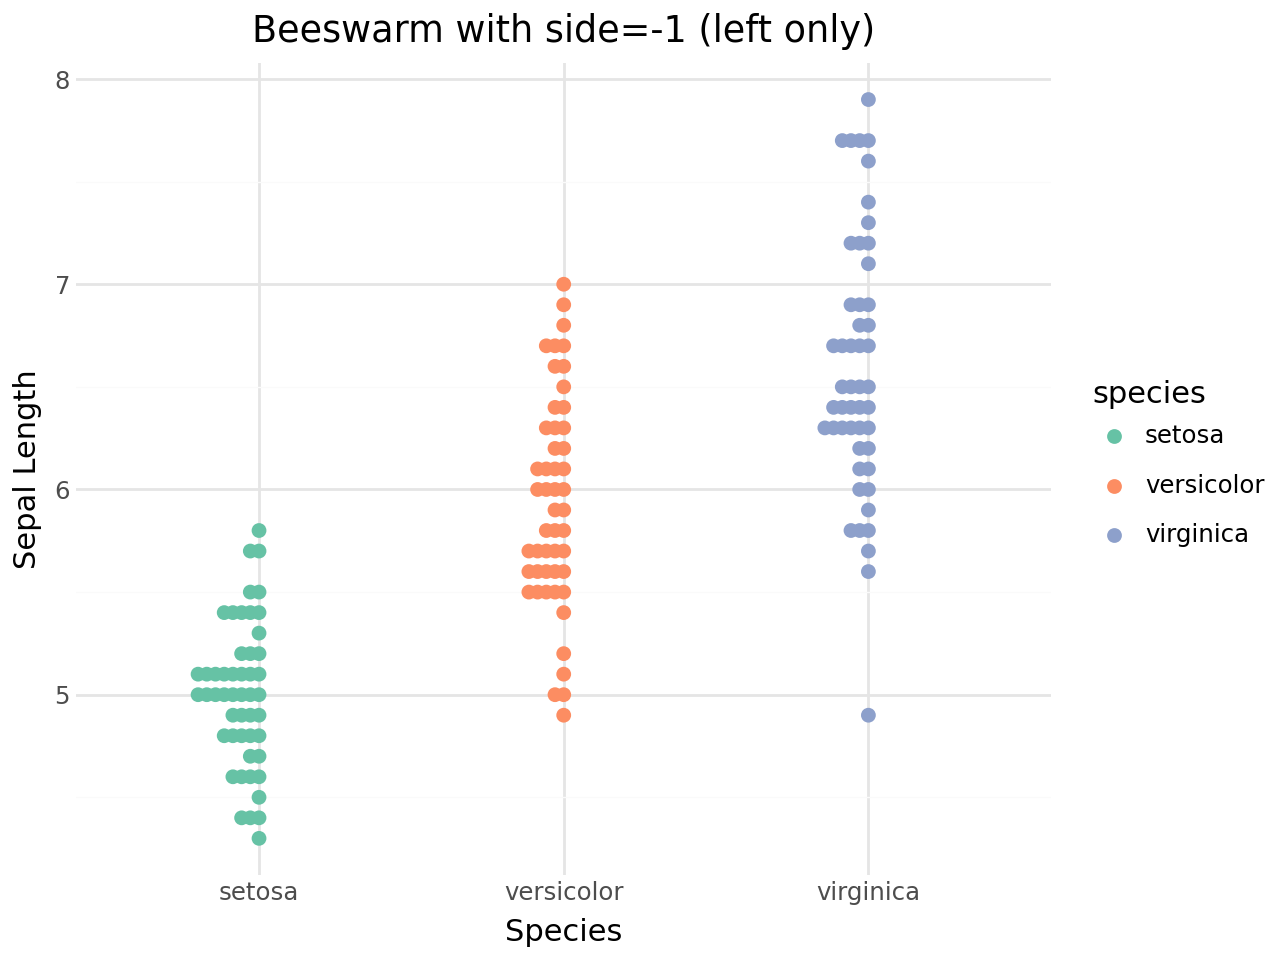

In [10]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(side=-1, size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title="Beeswarm with side=-1 (left only)",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Quasi-random jitter

`geom_quasirandom()` uses a density-aware quasi-random sequence to jitter
points. The result resembles a violin plot while retaining each observation.

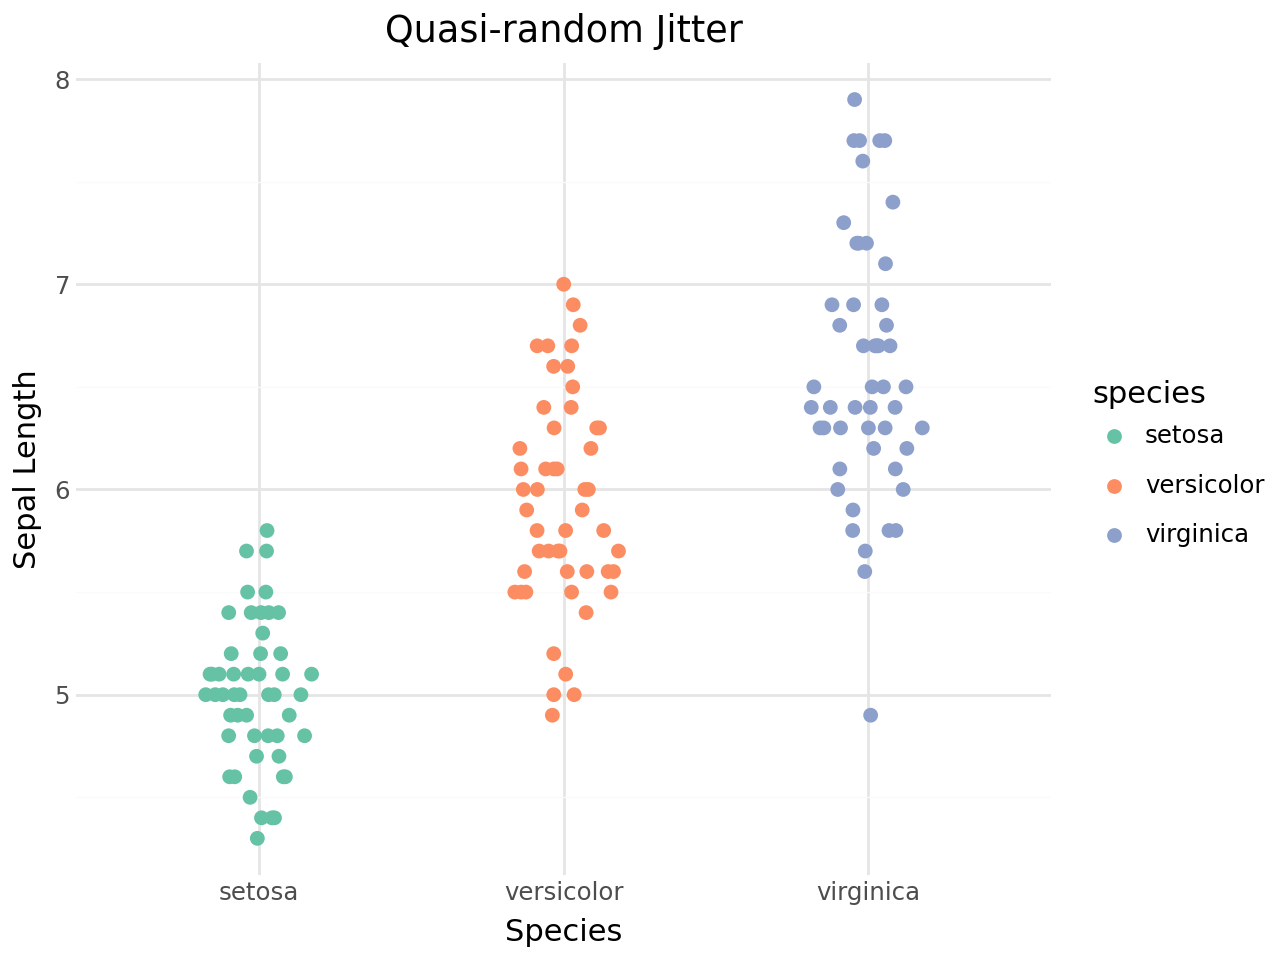

In [11]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_quasirandom(size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title="Quasi-random Jitter",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

### Pseudorandom method

Set `method="pseudorandom"` for uniform random jitter
instead of the quasi-random van der Corput sequence.

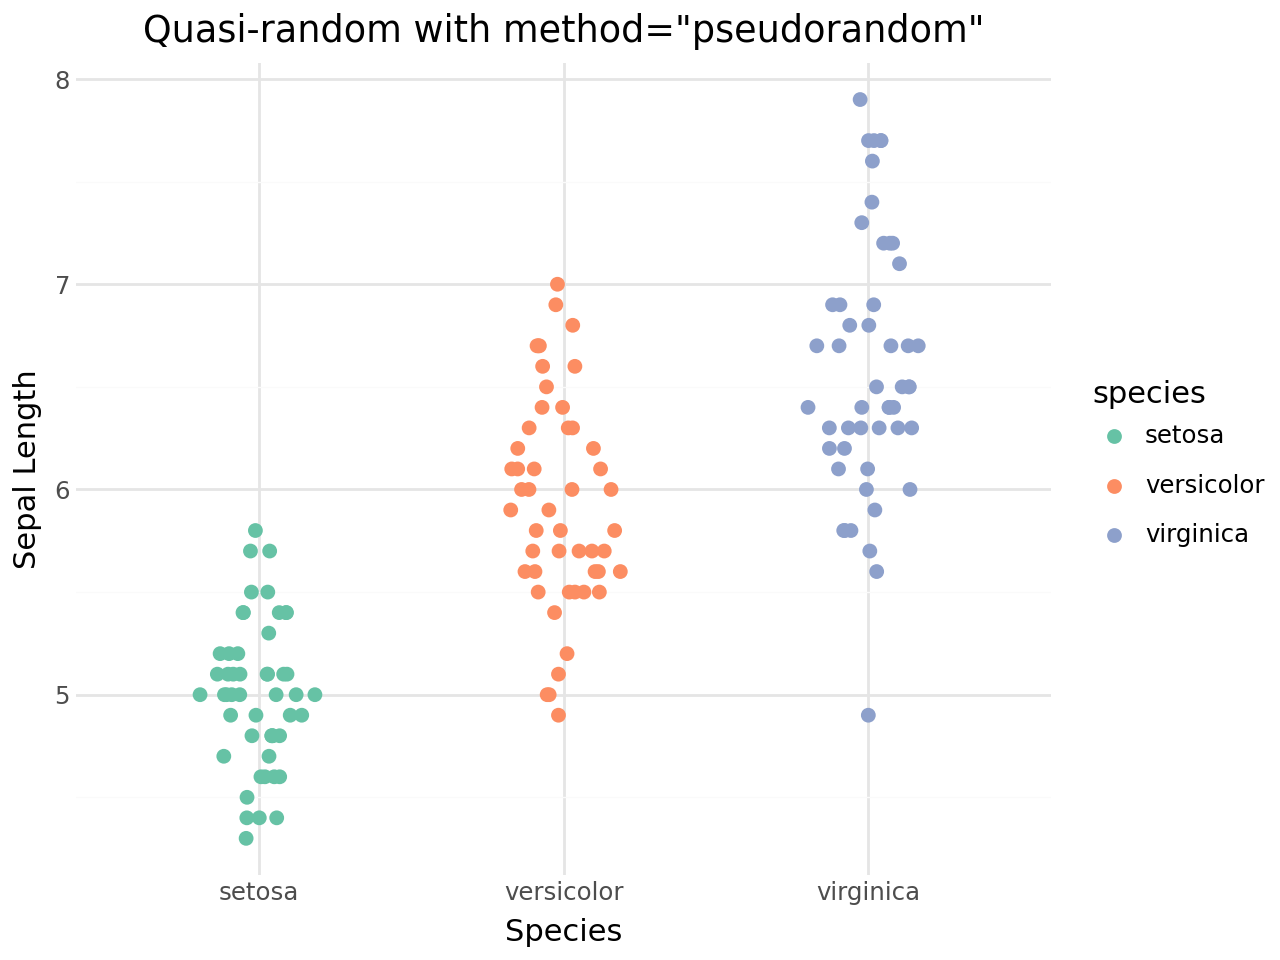

In [12]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_quasirandom(method="pseudorandom", size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title='Quasi-random with method="pseudorandom"',
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

### Controlling the jitter width

The `width` parameter sets the maximum horizontal spread.

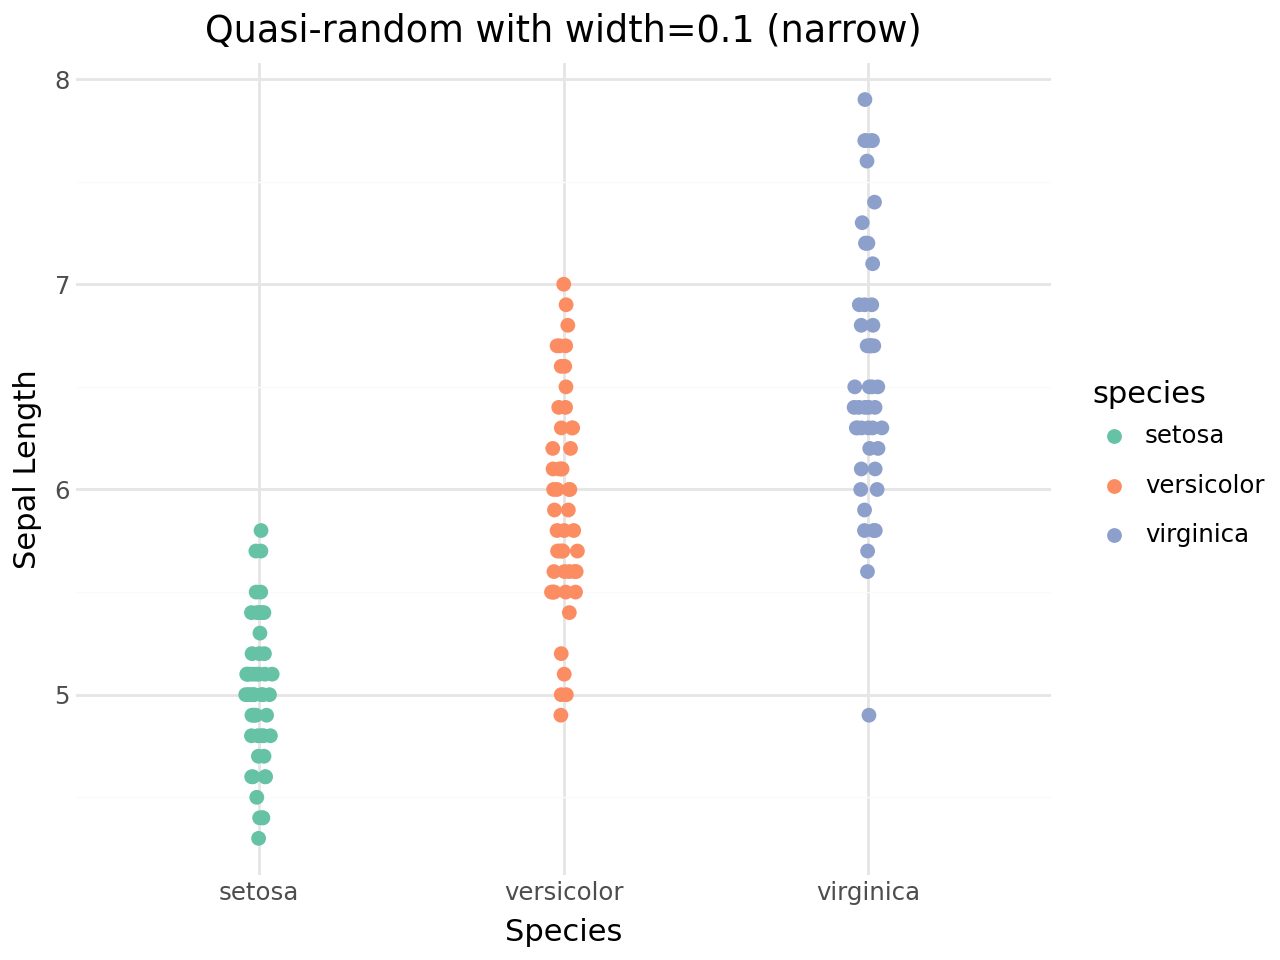

In [13]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_quasirandom(width=0.1, size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title="Quasi-random with width=0.1 (narrow)",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Combining with other geoms

Beeswarm points can be layered on box plots or violin plots to show raw
observations alongside distribution summaries.

### Beeswarm + Box plot

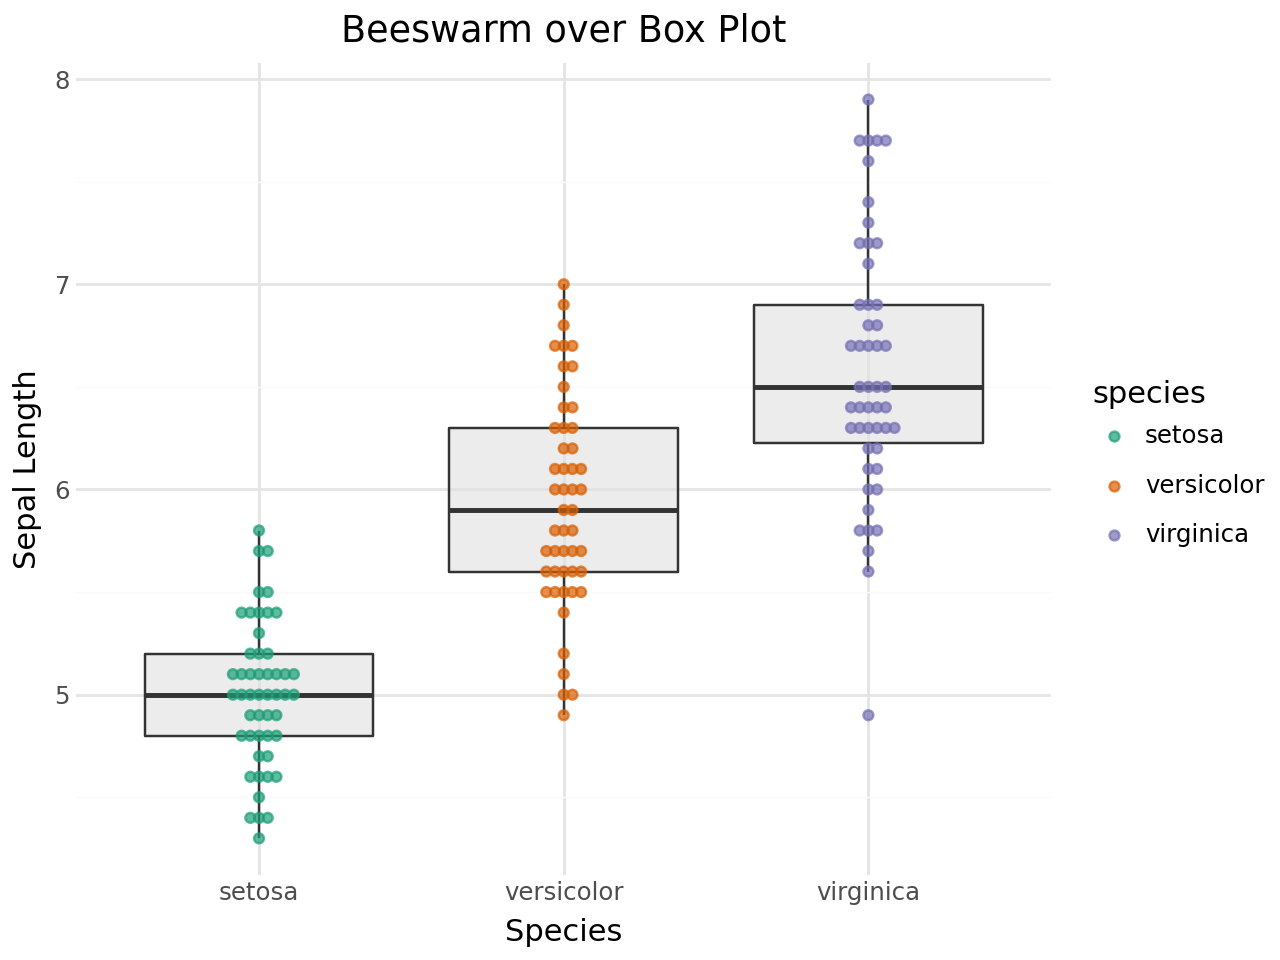

In [14]:
(
    ggplot(iris, aes(x="species", y="sepal_length"))
    + geom_boxplot(outlier_shape="", fill="#e0e0e0", alpha=0.6)
    + geom_beeswarm(aes(color="species"), size=1.5, alpha=0.7)
    + scale_color_brewer(type="qual", palette="Dark2")
    + labs(
        title="Beeswarm over Box Plot",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

### Quasi-random + Violin plot

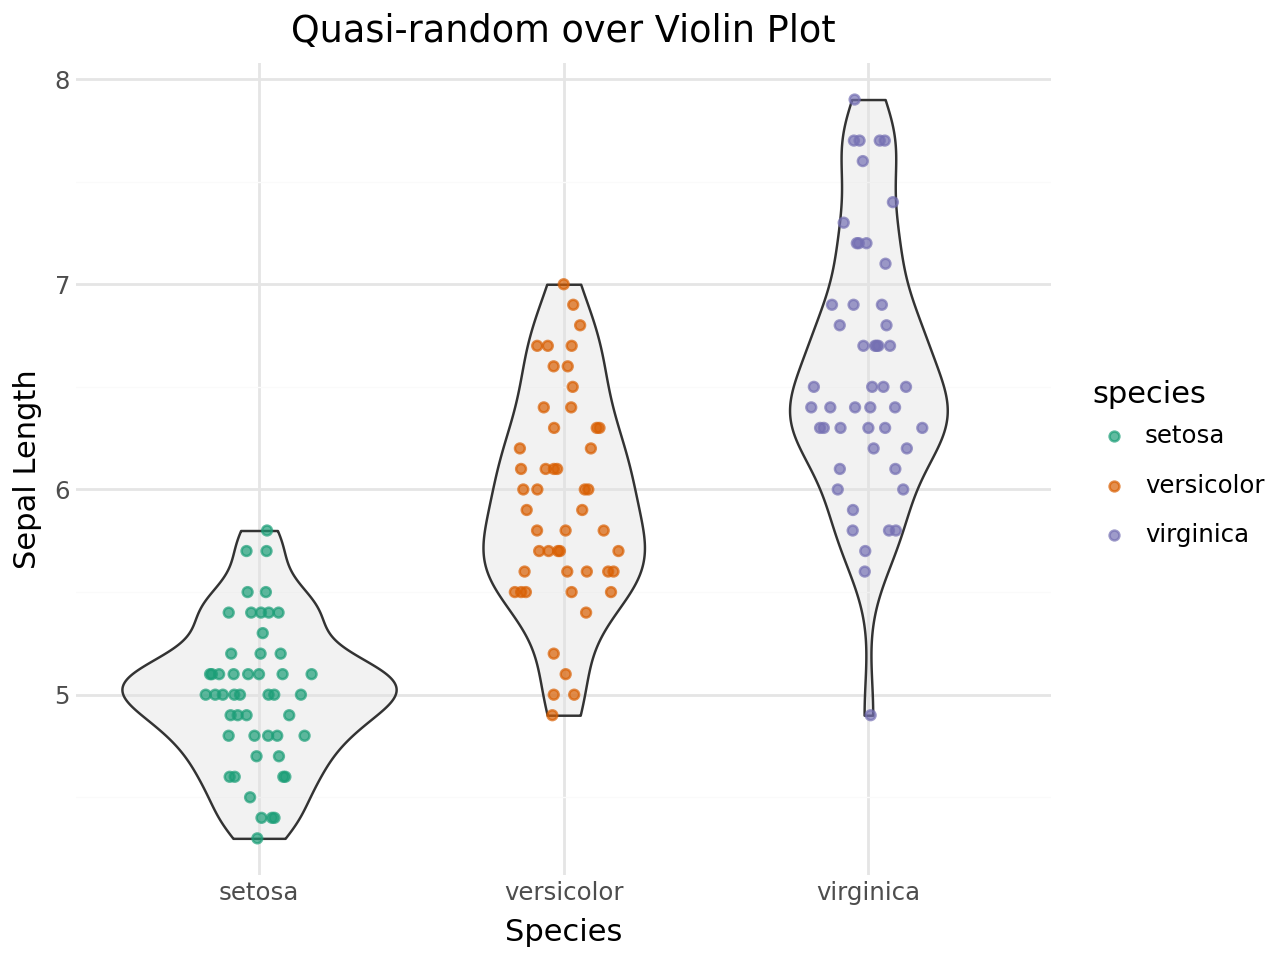

In [15]:
(
    ggplot(iris, aes(x="species", y="sepal_length"))
    + geom_violin(fill="#e0e0e0", alpha=0.4)
    + geom_quasirandom(aes(color="species"), size=1.5, alpha=0.7)
    + scale_color_brewer(type="qual", palette="Dark2")
    + labs(
        title="Quasi-random over Violin Plot",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Horizontal beeswarm

Use `coord_flip()` to produce a horizontal beeswarm plot.

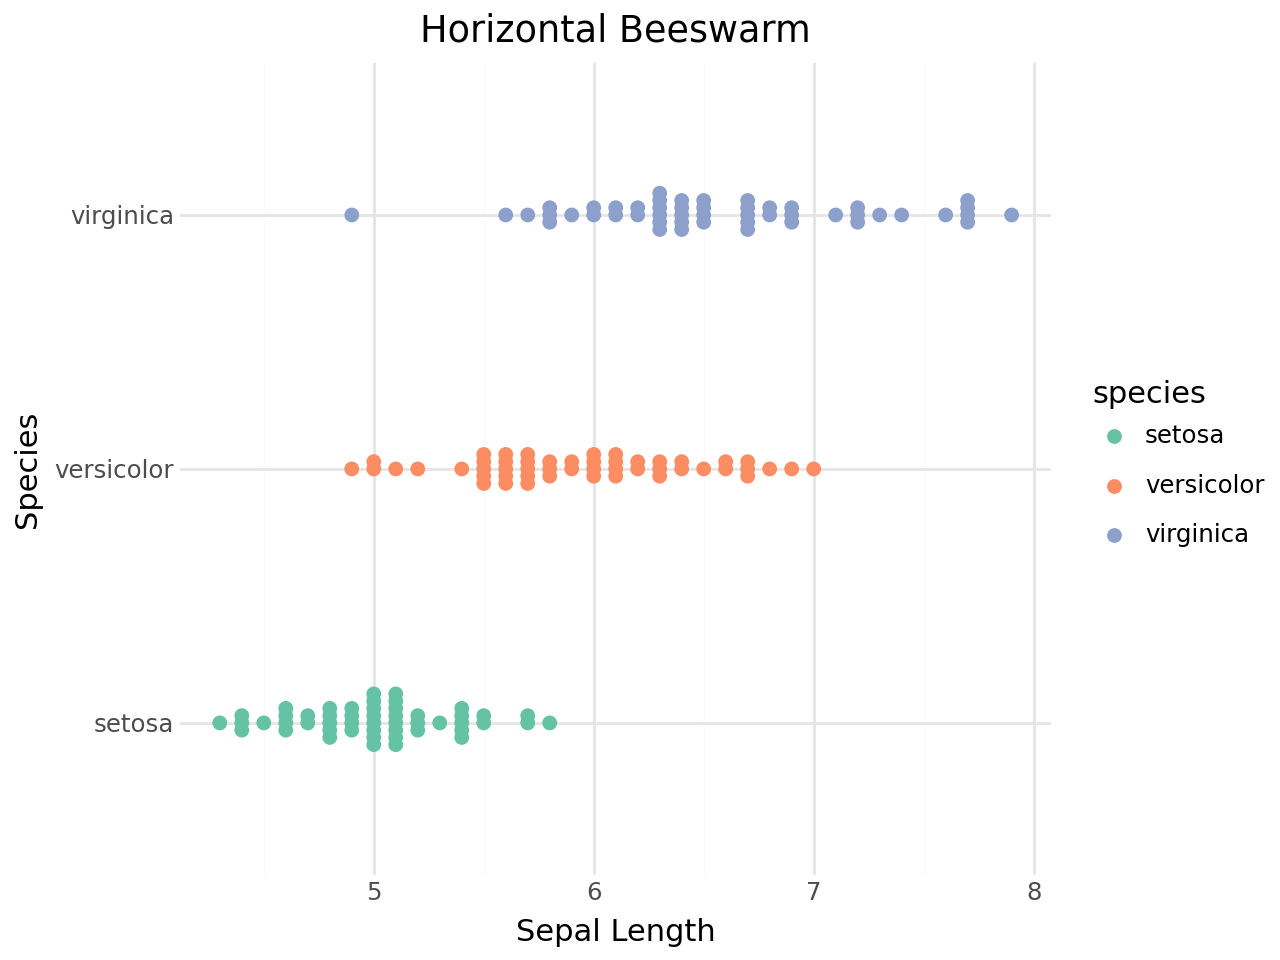

In [16]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + coord_flip()
    + labs(
        title="Horizontal Beeswarm",
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Priority ordering

The `priority` parameter controls the order in which points
are placed in the swarm.  This affects the final shape:

| Priority | Description |
|---|---|
| `"ascending"` | Points placed from smallest to largest (default) |
| `"descending"` | Points placed from largest to smallest |
| `"density"` | Dense regions placed first |
| `"random"` | Random placement order |
| `"none"` | Data order preserved |

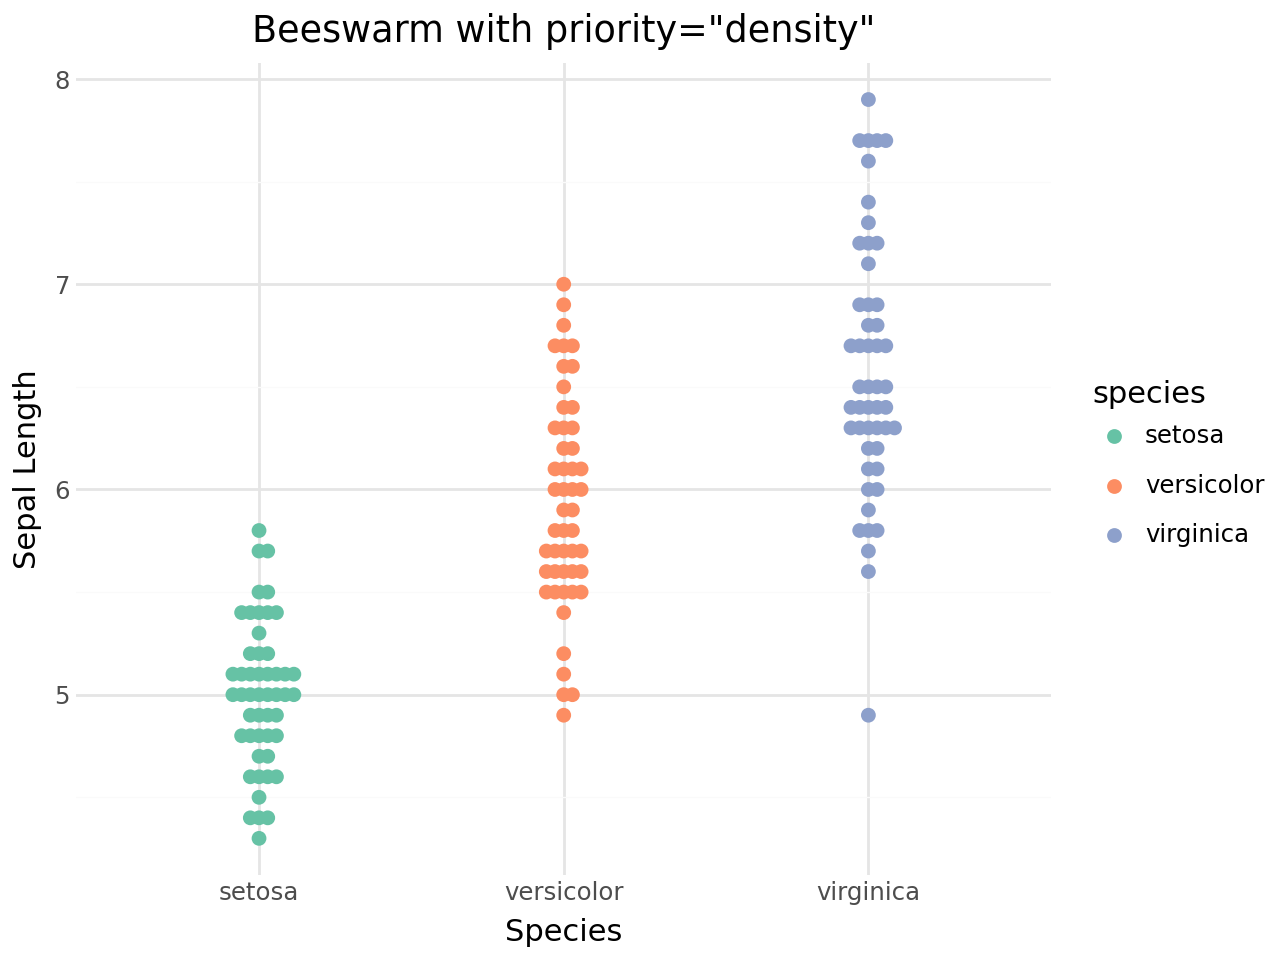

In [17]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(priority="density", size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title='Beeswarm with priority="density"',
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Corral (handling runaway points)

When groups are very dense, some points may extend far from
the group centre.  The `corral` parameter offers several
strategies to rein them in:

| Corral | Description |
|---|---|
| `"none"` | No correction (default) |
| `"gutter"` | Clamp to corral boundary |
| `"wrap"` | Wrap periodically |
| `"random"` | Random placement within corral |
| `"omit"` | Remove runaway points |

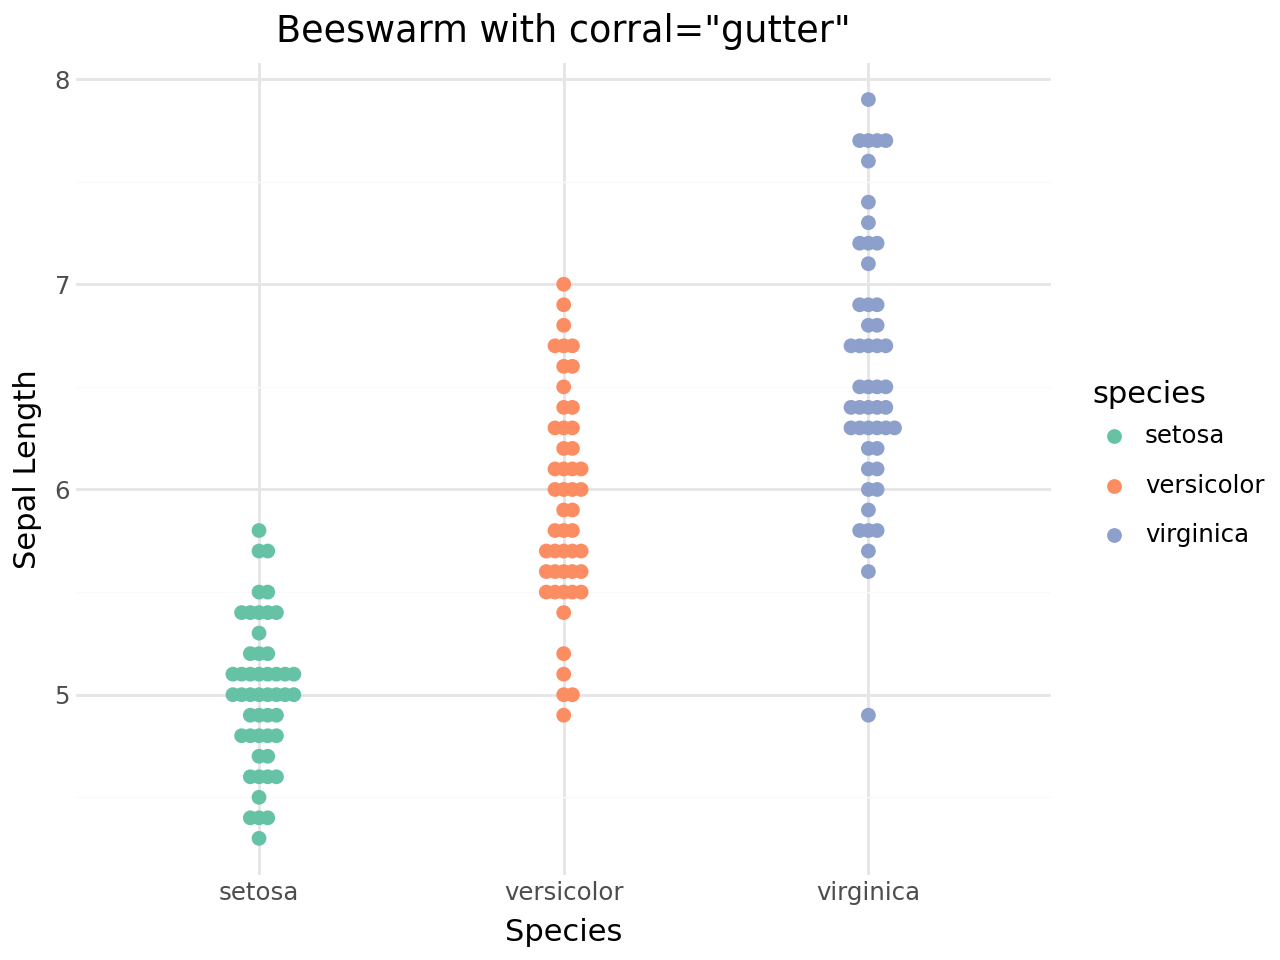

In [18]:
(
    ggplot(iris, aes(x="species", y="sepal_length", color="species"))
    + geom_beeswarm(corral="gutter", corral_width=0.4, size=2)
    + scale_color_brewer(type="qual", palette="Set2")
    + labs(
        title='Beeswarm with corral="gutter"',
        x="Species",
        y="Sepal Length",
    )
    + theme_minimal()
)

## Covered options

This vignette covered:

* `geom_beeswarm()` for collision-avoiding point placement.
* `geom_quasirandom()` for density-aware quasi-random jitter.
* Standard `geom_point()` aesthetics (`color`, `size`, `alpha`, `shape`, etc.).
* Layering with `geom_boxplot()` or `geom_violin()`.
* Layout controls: `cex`, `side`, `priority`, `method`, and `corral`.
* Constructor validation: invalid `method`, `priority`, `side`, or `corral`
  values raise `ValueError` instead of falling back silently.